Import Libraries


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Load Dataset


In [ ]:

housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add the target column (house prices)
df['Price'] = housing.target

print("Dataset loaded!")
print("Shape:", df.shape)

Dataset loaded!
Shape: (20640, 9)


In [ ]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Check for missing values


In [ ]:
print(df.isnull().sum())

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64


Normalize the Features

In [ ]:
X = df.drop('Price', axis=1).values
y = df['Price'].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20640, 8)
y shape: (20640,)


In [ ]:
print("Before normalization:")
print(f"  MedInc range:     {X[:,0].min():.2f}  to  {X[:,0].max():.2f}")
print(f"  Population range: {X[:,4].min():.2f}  to  {X[:,4].max():.2f}")
print(f"  AveRooms range:   {X[:,2].min():.2f}  to  {X[:,2].max():.2f}")

Before normalization:
  MedInc range:     0.50  to  15.00
  Population range: 3.00  to  35682.00
  AveRooms range:   0.85  to  141.91


In [ ]:
# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Verify
print("After normalization:")
print(f"  MedInc mean:     {X_scaled[:,0].mean():.4f}  (close to 0)")
print(f"  Population mean: {X_scaled[:,4].mean():.4f}  (close to 0)")
print(f"  MedInc std:      {X_scaled[:,0].std():.4f}   (close to 1)")
print(f"  Population std:  {X_scaled[:,4].std():.4f}   (close to 1)")

After normalization:
  MedInc mean:     0.0000  (close to 0)
  Population mean: -0.0000  (close to 0)
  MedInc std:      1.0000   (close to 1)
  Population std:  1.0000   (close to 1)


In [ ]:
# This time we split into THREE sets instead of two
# Train → model learns from this
# Validation → checked during training to monitor progress
# Test → final evaluation after training is complete

# First split: 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

# Second split: split that 20% into 10% val and 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)

print("Training samples:   ", X_train.shape[0])
print("Validation samples: ", X_val.shape[0])
print("Testing samples:    ", X_test.shape[0])

Training samples:    16512
Validation samples:  2064
Testing samples:     2064


Build the Regression ANN

In [ ]:
# Build the ANN for regression
model = keras.Sequential([

    # Hidden layer 1
    layers.Dense(64, activation='relu', input_shape=(8,), name='Hidden_Layer_1'),

    # Hidden layer 2
    layers.Dense(32, activation='relu', name='Hidden_Layer_2'),

    # Output layer
    # NO activation function = Linear activation
    # Outputs a single raw number (the predicted house price)
    layers.Dense(1, name='Output_Layer')

])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

 Compile the Model

In [ ]:

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print("Model compiled successfully!")

Model compiled successfully!


Train the Model

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7945 - mae: 0.6059 - val_loss: 0.4351 - val_mae: 0.4614
Epoch 2/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3957 - mae: 0.4488 - val_loss: 0.3856 - val_mae: 0.4380
Epoch 3/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3684 - mae: 0.4316 - val_loss: 0.3717 - val_mae: 0.4335
Epoch 4/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3530 - mae: 0.4176 - val_loss: 0.3573 - val_mae: 0.4132
Epoch 5/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3566 - mae: 0.4080 - val_loss: 0.3466 - val_mae: 0.4099
Epoch 6/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3263 - mae: 0.3991 - val_loss: 0.3444 - val_mae: 0.4126
Epoch 7/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3261 - mae: 0.3938 - val_loss: 0.3380 - val_mae: 0.4058
Epoch 8/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3135 - mae: 0.3881 - val_loss: 0.3227 - val_mae: 0.3858
Epoch 9/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/

loss plots

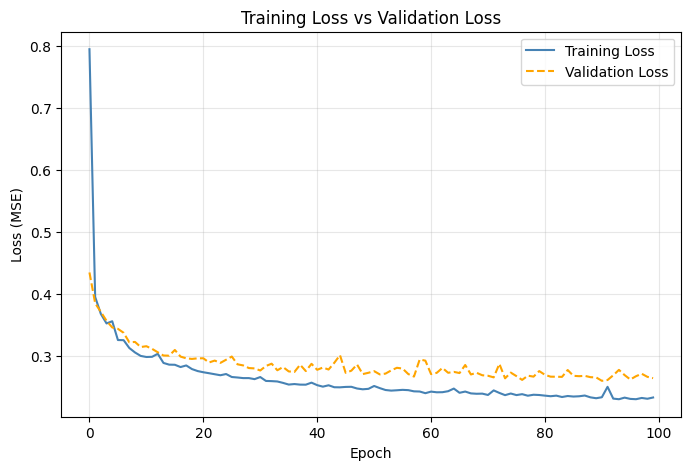

In [ ]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'],     label='Training Loss',   color='steelblue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linestyle='--')
plt.title('Training Loss vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Evaluate the Model

In [ ]:
# Generate predictions on the test set
y_pred = model.predict(X_test).flatten()

print("Predictions done!")
print("Sample predictions vs actual:")
for i in range(5):
    print(f"  Predicted: ${y_pred[i]*100:.1f}k   Actual: ${y_test[i]*100:.1f}k")

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Predictions done!
Sample predictions vs actual:
  Predicted: $298.2k   Actual: $238.5k
  Predicted: $209.7k   Actual: $329.7k
  Predicted: $136.7k   Actual: $95.2k
  Predicted: $251.5k   Actual: $245.1k
  Predicted: $86.2k   Actual: $64.1k


In [ ]:
# Calculate all four metrics
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("===== MODEL PERFORMANCE =====")
print(f"MAE  (Mean Absolute Error)       : {mae:.4f}")
print(f"MSE  (Mean Squared Error)        : {mse:.4f}")
print(f"RMSE (Root Mean Squared Error)   : {rmse:.4f}")
print(f"R²   (R Squared Score)           : {r2:.4f}")

===== MODEL PERFORMANCE =====
MAE  (Mean Absolute Error)       : 0.3535
MSE  (Mean Squared Error)        : 0.2728
RMSE (Root Mean Squared Error)   : 0.5223
R²   (R Squared Score)           : 0.7907


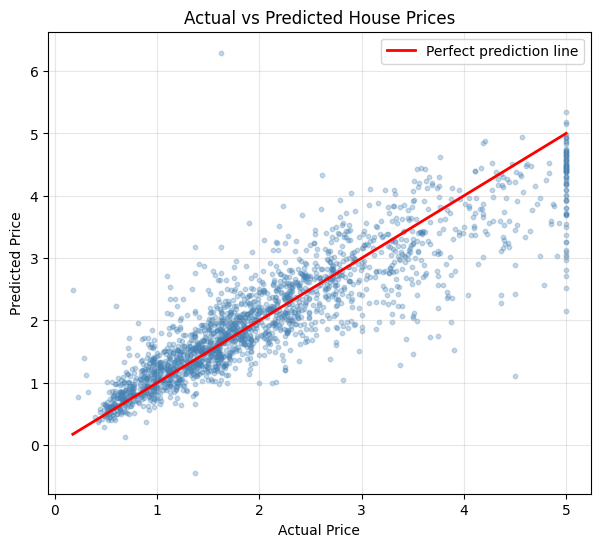

In [ ]:
# Plot 1 — Actual vs Predicted
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2, label='Perfect prediction line')
plt.title('Actual vs Predicted House Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

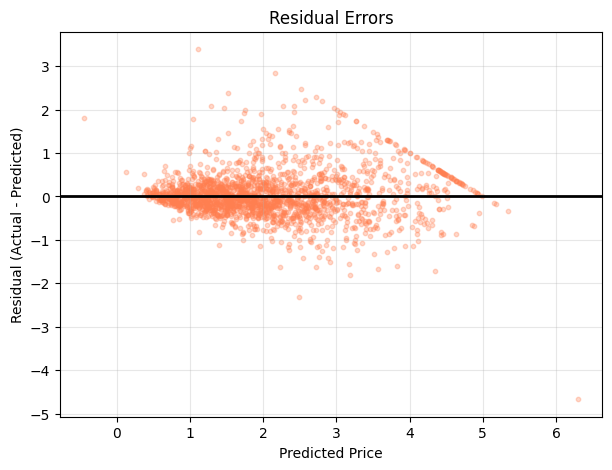

In [ ]:
# Plot 2 — Residual Errors
residuals = y_test - y_pred

plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals, alpha=0.3, color='coral', s=10)
plt.axhline(y=0, color='black', linewidth=2)
plt.title('Residual Errors')
plt.xlabel('Predicted Price')
plt.ylabel('Residual (Actual - Predicted)')
plt.grid(True, alpha=0.3)
plt.show()

 Experimental Analysis

In [ ]:
# A function that builds, trains and evaluates a model in one go
# This saves us from rewriting the same code every time

def run_experiment(learning_rate, hidden_layers, batch_size, optimizer_name):

    # Build model based on hidden_layers input
    model = keras.Sequential()

    # Input + first hidden layer
    model.add(layers.Dense(hidden_layers[0], activation='relu', input_shape=(8,)))

    # Add remaining hidden layers
    for units in hidden_layers[1:]:
        model.add(layers.Dense(units, activation='relu'))

    # Output layer
    model.add(layers.Dense(1))

    # Choose optimizer
    if optimizer_name == 'adam':
        opt = keras.optimizers.Adam(learning_rate=learning_rate)
    else:
        opt = keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)

    # Compile
    model.compile(optimizer=opt, loss='mse', metrics=['mae'])

    # Train
    model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=batch_size,
        validation_data=(X_val, y_val),
        verbose=0       # silent training, no scrolling output
    )

    # Evaluate
    y_pred = model.predict(X_test, verbose=0).flatten()
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    return mae, rmse, r2

print("Function ready!")

Function ready!


In [ ]:
# Run all experiments

results = []

# Experiment 1 — Baseline (what you already built)
mae, rmse, r2 = run_experiment(0.001, [64, 32], 32, 'adam')
results.append(['Adam | lr=0.001 | [64,32] | batch=32', mae, rmse, r2])
print("Experiment 1 done ✓")

# Experiment 2 — Higher learning rate
mae, rmse, r2 = run_experiment(0.01, [64, 32], 32, 'adam')
results.append(['Adam | lr=0.01  | [64,32] | batch=32', mae, rmse, r2])
print("Experiment 2 done ✓")

# Experiment 3 — Lower learning rate
mae, rmse, r2 = run_experiment(0.0001, [64, 32], 32, 'adam')
results.append(['Adam | lr=0.0001| [64,32] | batch=32', mae, rmse, r2])
print("Experiment 3 done ✓")

# Experiment 4 — Deeper network (more hidden layers)
mae, rmse, r2 = run_experiment(0.001, [128, 64, 32], 32, 'adam')
results.append(['Adam | lr=0.001 | [128,64,32] | batch=32', mae, rmse, r2])
print("Experiment 4 done ✓")

# Experiment 5 — Larger batch size
mae, rmse, r2 = run_experiment(0.001, [64, 32], 64, 'adam')
results.append(['Adam | lr=0.001 | [64,32] | batch=64', mae, rmse, r2])
print("Experiment 5 done ✓")

# Experiment 6 — SGD optimizer
mae, rmse, r2 = run_experiment(0.01, [64, 32], 32, 'sgd')
results.append(['SGD  | lr=0.01  | [64,32] | batch=32', mae, rmse, r2])
print("Experiment 6 done ✓")

print("\nAll experiments complete!")

Running experiments... please wait



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Experiment 1 done ✓


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Experiment 2 done ✓


...

Experiment 4 done ✓


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Experiment 5 done ✓


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Experiment 6 done ✓

All experiments complete!
